# EE 446 TinyML — Knowledge Distillation with Pruning and Quantization  

## Student TODO Version: Compression of a DNN Using the UCI Human Activity Recognition Dataset

In this version, key parts of the notebook have been left for you to complete.  
Follow the instructions in each code cell and fill in the missing sections marked with `#<--- Enter your code here --->#`.


## 1. Environment Setup

This notebook assumes you are running it with the **`Python (tinyml-arduino)`** kernel.

Expected environment:
- TensorFlow 2.14.1
- TensorFlow Model Optimization 0.8.0
- NumPy, Pandas, Matplotlib, Scikit-learn
- No in-notebook package reinstallation is required

Use **Kernel → Change Kernel → `Python (tinyml-arduino)`** if needed.


In [1]:

import os
import math
import zipfile
import random
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from tensorflow_model_optimization.sparsity.keras import (
    prune_low_magnitude,
    PolynomialDecay,
    UpdatePruningStep,
    strip_pruning
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)


2026-07-21 06:41:19.030776: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-21 06:41:19.109976: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-21 06:41:19.110011: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-21 06:41:19.110038: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-21 06:41:19.120313: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-21 06:41:19.120976: I tensorflow/core/platform/cpu_feature_guard.cc:182] This Tens

TensorFlow version: 2.14.1


## 2. Download and Extract the UCI HAR Dataset

The UCI HAR dataset contains:
- **561 numerical features** extracted from smartphone sensor signals
- **6 human activity classes**
- A predefined **training split** and **test split**

This makes it a strong fit for a **fully connected DNN** and for TinyML-oriented compression experiments.


In [2]:

dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = Path("uci_har_dataset.zip")
extract_dir = Path(".")

if not zip_path.exists():
    print("Downloading dataset...")
    urllib.request.urlretrieve(dataset_url, zip_path)

dataset_root = Path("UCI HAR Dataset")
if not dataset_root.exists():
    print("Extracting dataset...")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)

print("Dataset ready at:", dataset_root.resolve())


Dataset ready at: /home/vboxuser/TinyML/UCI HAR Dataset


## 3. Load the Data


In [3]:

def load_har_data(root_dir="UCI HAR Dataset"):
    root_dir = Path(root_dir)

    # TODO:
    # 1. Load X_train from train/X_train.txt as float32
    # 2. Load y_train from train/y_train.txt as int32 and subtract 1
    # 3. Load X_test from test/X_test.txt as float32
    # 4. Load y_test from test/y_test.txt as int32 and subtract 1

    x_train = np.loadtxt(os.path.join(root_dir, "train", "X_train.txt"))
    y_train = np.loadtxt(os.path.join(root_dir, "train", "y_train.txt"))
    x_test = np.loadtxt(os.path.join(root_dir, "test", "X_test.txt"))
    y_test = np.loadtxt(os.path.join(root_dir, "test", "y_test.txt"))
    return x_train-1, y_train-1, x_test-1, y_test-1 

x_train, y_train, x_test, y_test = load_har_data(dataset_root)

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING",
]

num_features = x_train.shape[1]
num_classes = len(class_names)

print("X_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape :", x_test.shape)
print("y_test shape :", y_test.shape)
print("Number of features:", num_features)
print("Number of classes :", num_classes)


X_train shape: (7352, 561)
y_train shape: (7352,)
X_test shape : (2947, 561)
y_test shape : (2947,)
Number of features: 561
Number of classes : 6


## 4. Quick Inspection


In [4]:

label_counts = pd.Series(y_train).value_counts().sort_index()

dataset_summary = pd.DataFrame({
    "Class Index": list(range(num_classes)),
    "Class Name": class_names,
    "Training Samples": label_counts.values,
})

dataset_summary


,Class Index,Class Name,Training Samples
0,0,WALKING,1226
1,1,WALKING_UPSTAIRS,1073
2,2,WALKING_DOWNSTAIRS,986
3,3,SITTING,1286
4,4,STANDING,1374
5,5,LAYING,1407


## 5. Define the Teacher and Student Models

The **teacher model** is intentionally larger and more expressive.  
The **student model** is smaller and is the model we ultimately want to deploy.


In [5]:

def build_teacher_model(input_dim, num_classes):
    # TODO:
    # Build a larger teacher DNN suitable for 561 numerical input features.
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(512, activation="relu"),
        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ])
    return model

def build_student_model(input_dim, num_classes):
    # TODO:
    # Build a smaller student DNN.
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ])
    return model

teacher_model = build_teacher_model(num_features, num_classes)
student_baseline_model = build_student_model(num_features, num_classes)

print("Teacher  Model Summary")
teacher_model.summary()
print("Student  Model Summary")
student_baseline_model.summary()


Teacher  Model Summary
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 512)               287744    
                                                                 
 dense_1 (Dense)             (None, 256)               131328    
                                                                 
 dense_2 (Dense)             (None, 128)               32896     
                                                                 
 dense_3 (Dense)             (None, 6)                 774       
                                                                 
Total params: 452742 (1.73 MB)
Trainable params: 452742 (1.73 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Student  Model Summary
Model: "sequential_1"
_________________________________________________________________
 Layer (type)     

## 6. Train the Teacher Model


In [7]:

teacher_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

teacher_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=10,
        restore_best_weights=True
    )
]

# TODO:
# Train the teacher model on the UCI HAR training split.
teacher_history = teacher_model.fit(
    x_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=teacher_callbacks,
    verbose=1
)

Epoch 1/20
92/92 [==============================] - 2s 9ms/step - loss: 0.2933 - accuracy: 0.8888 - val_loss: 0.1750 - val_accuracy: 0.9409
Epoch 2/20
92/92 [==============================] - 1s 7ms/step - loss: 0.1940 - accuracy: 0.9187 - val_loss: 0.1872 - val_accuracy: 0.9143
Epoch 3/20
92/92 [==============================] - 1s 6ms/step - loss: 0.1917 - accuracy: 0.9209 - val_loss: 0.2656 - val_accuracy: 0.8899
Epoch 4/20
92/92 [==============================] - 1s 7ms/step - loss: 0.2435 - accuracy: 0.9027 - val_loss: 0.1477 - val_accuracy: 0.9449
Epoch 5/20
92/92 [==============================] - 1s 6ms/step - loss: 0.1779 - accuracy: 0.9221 - val_loss: 0.1654 - val_accuracy: 0.9381
Epoch 6/20
92/92 [==============================] - 1s 7ms/step - loss: 0.1658 - accuracy: 0.9327 - val_loss: 0.1539 - val_accuracy: 0.9252
Epoch 7/20
92/92 [==============================] - 1s 7ms/step - loss: 0.1327 - accuracy: 0.9430 - val_loss: 0.2563 - val_accuracy: 0.9062
Epoch 8/20
92/92 [==

### Teacher Training Curves


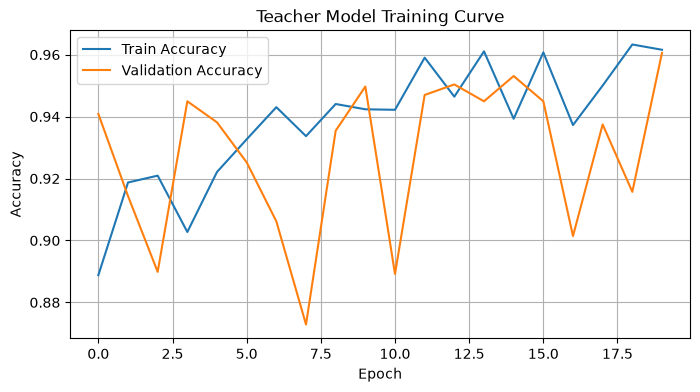

In [8]:

teacher_history_df = pd.DataFrame(teacher_history.history)

plt.figure(figsize=(8, 4))
plt.plot(teacher_history_df["accuracy"], label="Train Accuracy")
plt.plot(teacher_history_df["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Teacher Model Training Curve")
plt.legend()
plt.grid(True)
plt.show()


## 7. Evaluate the Teacher Model


Test Accuracy: 0.9372

                    precision    recall  f1-score   support

           WALKING     0.9271    0.9738    0.9499       496
  WALKING_UPSTAIRS     0.9650    0.8769    0.9188       471
WALKING_DOWNSTAIRS     0.9227    0.9667    0.9442       420
           SITTING     0.9515    0.8391    0.8918       491
          STANDING     0.8693    0.9624    0.9135       532
            LAYING     1.0000    0.9981    0.9991       537

          accuracy                         0.9372      2947
         macro avg     0.9393    0.9362    0.9362      2947
      weighted avg     0.9394    0.9372    0.9368      2947



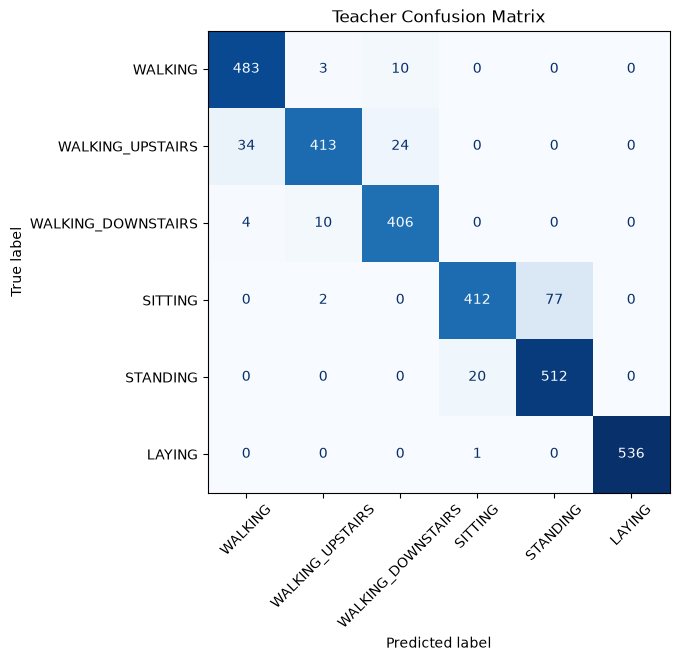

In [13]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
probs = teacher_model.predict(x_test, verbose=0)
preds = np.argmax(probs, axis=1)
teacher_acc = accuracy_score(y_test, preds)

print(f"Test Accuracy: {teacher_acc:.4f}\n")
print(classification_report(y_test, preds, target_names=class_names, digits=4))

disp = ConfusionMatrixDisplay(
confusion_matrix=confusion_matrix(y_test, preds),
display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Teacher Confusion Matrix")
plt.show()


## 8. Train a Baseline Student Model (Hard Labels Only)

Before applying knowledge distillation, we train the smaller student model in the standard way.  
This gives us a fair baseline for comparison.


In [10]:

student_baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

student_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

student_baseline_history = student_baseline_model.fit(
    x_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=student_callbacks,
    verbose=1
)


Epoch 1/20
92/92 [==============================] - 1s 5ms/step - loss: 0.9690 - accuracy: 0.5979 - val_loss: 0.5587 - val_accuracy: 0.7961
Epoch 2/20
92/92 [==============================] - 0s 3ms/step - loss: 0.4637 - accuracy: 0.8349 - val_loss: 0.4451 - val_accuracy: 0.7974
Epoch 3/20
92/92 [==============================] - 0s 4ms/step - loss: 0.3772 - accuracy: 0.8483 - val_loss: 0.3203 - val_accuracy: 0.9001
Epoch 4/20
92/92 [==============================] - 0s 4ms/step - loss: 0.2868 - accuracy: 0.8895 - val_loss: 0.2232 - val_accuracy: 0.9205
Epoch 5/20
92/92 [==============================] - 0s 3ms/step - loss: 0.2547 - accuracy: 0.8993 - val_loss: 0.2578 - val_accuracy: 0.9096
Epoch 6/20
92/92 [==============================] - 0s 4ms/step - loss: 0.2313 - accuracy: 0.9072 - val_loss: 0.1789 - val_accuracy: 0.9279
Epoch 7/20
92/92 [==============================] - 0s 5ms/step - loss: 0.2159 - accuracy: 0.9141 - val_loss: 0.2155 - val_accuracy: 0.9041
Epoch 8/20
92/92 [==

## 9. Evaluate the Baseline Student Model


Test Accuracy: 0.9372

                    precision    recall  f1-score   support

           WALKING     0.7990    0.9940    0.8859       496
  WALKING_UPSTAIRS     0.9136    0.8301    0.8699       471
WALKING_DOWNSTAIRS     0.9942    0.8190    0.8982       420
           SITTING     0.9450    0.8045    0.8691       491
          STANDING     0.8436    0.9530    0.8950       532
            LAYING     1.0000    1.0000    1.0000       537

          accuracy                         0.9050      2947
         macro avg     0.9159    0.9001    0.9030      2947
      weighted avg     0.9141    0.9050    0.9047      2947



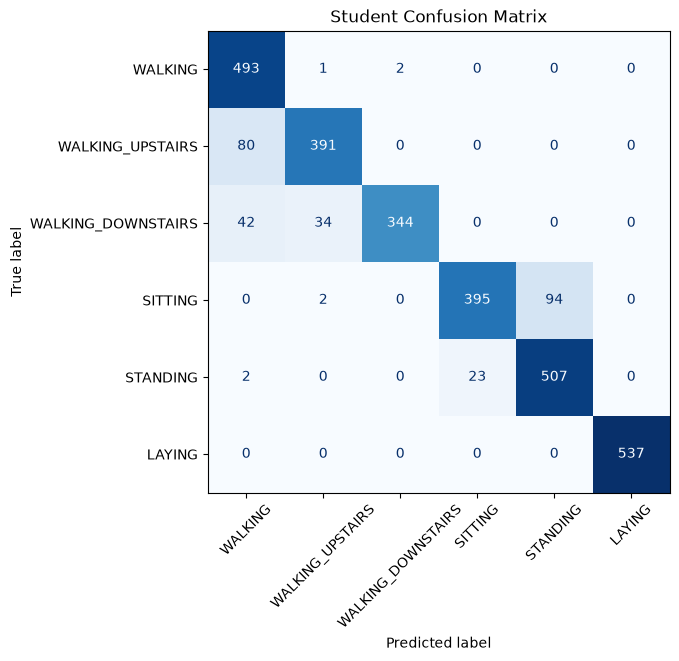

In [12]:
stud_probs = student_baseline_model.predict(x_test, verbose=0)
stud_preds = np.argmax(stud_probs, axis=1)
stud_acc = accuracy_score(y_test, preds)

print(f"Test Accuracy: {stud_acc:.4f}\n")
print(classification_report(y_test, stud_preds, target_names=class_names, digits=4))

disp = ConfusionMatrixDisplay(
confusion_matrix=confusion_matrix(y_test, stud_preds),
display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Student Confusion Matrix")
plt.show()


# Part I: Knowledge Distillation

## 10. Distillation Utilities

The distilled student is trained to optimize:
- a **hard-label loss** using the true class labels
- a **soft-label loss** using the teacher's softened probability distribution


In [20]:
class Distiller(keras.Model):
    def __init__(self, student, teacher):
        super().__init__()
        self.teacher = teacher
        self.student = student

    def compile(
        self,
        optimizer,
        metrics,
        student_loss_fn,
        distillation_loss_fn,
        alpha=0.3,
        temperature=4.0,
    ):
        super().compile(optimizer=optimizer, metrics=metrics)
        self.student_loss_fn = student_loss_fn
        self.distillation_loss_fn = distillation_loss_fn
        self.alpha = alpha
        self.temperature = temperature

    def train_step(self, data):
        x, y = data

        # TODO:
        # 1. Obtain teacher predictions with training=False
        # 2. Compute student predictions inside GradientTape
        # 3. Compute student_loss using the hard labels
        # 4. Compute distillation_loss using softened teacher/student outputs
        # 5. Combine the two losses using alpha
        teacher_predictions = self.teacher(x, training=False)

        with tf.GradientTape() as tape:
            student_predictions = self.student(x, training=True)
            student_loss = self.student_loss_fn(y, student_predictions)

            distillation_loss = self.distillation_loss_fn(
                tf.nn.softmax(teacher_predictions / self.temperature, axis=1),
                tf.nn.softmax(student_predictions / self.temperature, axis=1),
            ) * (self.temperature ** 2)
            
            loss = self.alpha * student_loss + (1.0 - self.alpha) * distillation_loss

        trainable_vars = self.student.trainable_variables
        gradients = tape.gradient(loss, trainable_vars)
        self.optimizer.apply_gradients(zip(gradients, trainable_vars))

        self.compiled_metrics.update_state(y, student_predictions)

        results = {m.name: m.result() for m in self.metrics}
        results.update({
            "student_loss": student_loss,
            "distillation_loss": distillation_loss,
        })
        return results

    def test_step(self, data):
        x, y = data
        y_prediction = self.student(x, training=False)

        student_loss = self.student_loss_fn(y, y_prediction)
        self.compiled_metrics.update_state(y, y_prediction)

        results = {m.name: m.result() for m in self.metrics}
        results.update({"student_loss": student_loss})
        return results

## 11. Train the Distilled Student


In [16]:
distilled_student = build_student_model(num_features, num_classes)

distiller = Distiller(student=distilled_student, teacher=teacher_model)
distiller.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
    student_loss_fn=keras.losses.SparseCategoricalCrossentropy(),
    distillation_loss_fn=keras.losses.KLDivergence(),
    alpha=0.3,
    temperature=4.0,
)

distillation_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=10,
        restore_best_weights=True
    )
]

# TODO:
# Train the distilled student.
distillation_history = distiller.fit(
    x_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=distillation_callbacks,
    verbose=1
)

Epoch 1/20
92/92 [==============================] - 1s 6ms/step - accuracy: 0.5531 - student_loss: 1.1561 - distillation_loss: 0.0497 - val_accuracy: 0.8192 - val_student_loss: 0.5418
Epoch 2/20
92/92 [==============================] - 1s 6ms/step - accuracy: 0.8167 - student_loss: 0.5165 - distillation_loss: 0.0222 - val_accuracy: 0.8613 - val_student_loss: 0.3112
Epoch 3/20
92/92 [==============================] - 0s 4ms/step - accuracy: 0.8522 - student_loss: 0.3822 - distillation_loss: 0.0156 - val_accuracy: 0.8797 - val_student_loss: 0.2693
Epoch 4/20
92/92 [==============================] - 0s 5ms/step - accuracy: 0.8951 - student_loss: 0.2852 - distillation_loss: 0.0104 - val_accuracy: 0.9157 - val_student_loss: 0.0867
Epoch 5/20
92/92 [==============================] - 0s 5ms/step - accuracy: 0.8946 - student_loss: 0.2670 - distillation_loss: 0.0100 - val_accuracy: 0.9320 - val_student_loss: 0.0558
Epoch 6/20
92/92 [==============================] - 0s 4ms/step - accuracy: 0.90

### Distillation Training Curves


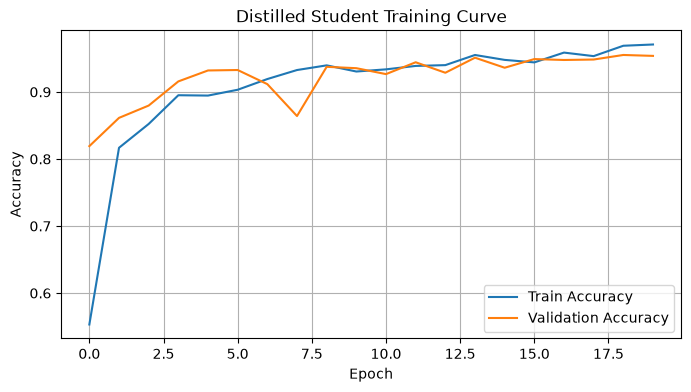

In [17]:

distillation_history_df = pd.DataFrame(distillation_history.history)

plt.figure(figsize=(8, 4))
plt.plot(distillation_history_df["accuracy"], label="Train Accuracy")
plt.plot(distillation_history_df["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Distilled Student Training Curve")
plt.legend()
plt.grid(True)
plt.show()


## 12. Evaluate the Distilled Student


Distilled Student Test Accuracy: 0.9141

                    precision    recall  f1-score   support

           WALKING     0.8303    0.9960    0.9056       496
  WALKING_UPSTAIRS     0.9296    0.8408    0.8829       471
WALKING_DOWNSTAIRS     0.9919    0.8738    0.9291       420
           SITTING     0.9424    0.8004    0.8656       491
          STANDING     0.8422    0.9530    0.8942       532
            LAYING     1.0000    1.0000    1.0000       537

          accuracy                         0.9141      2947
         macro avg     0.9227    0.9107    0.9129      2947
      weighted avg     0.9209    0.9141    0.9138      2947



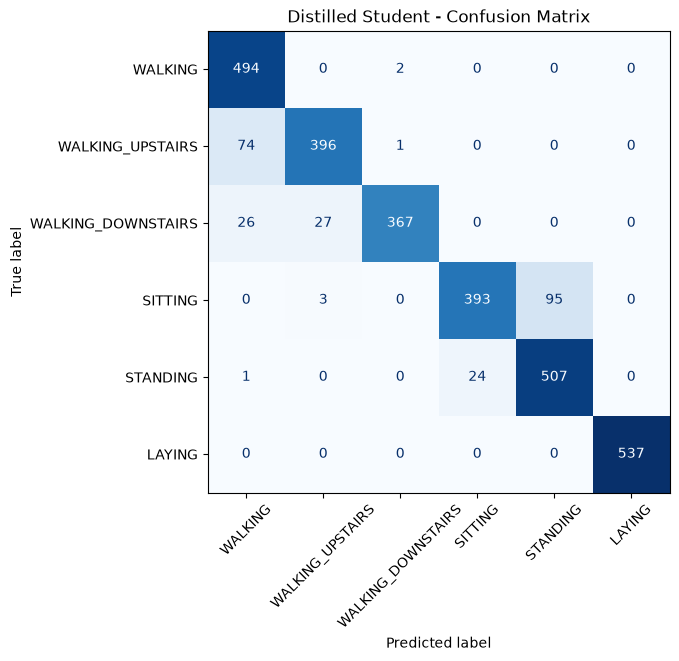

In [19]:

distilled_probs = distilled_student.predict(x_test, verbose=0)
distilled_preds = np.argmax(distilled_probs, axis=1)
distilled_acc = accuracy_score(y_test, distilled_preds)

print(f"Distilled Student Test Accuracy: {distilled_acc:.4f}\n")
print(classification_report(y_test, distilled_preds, target_names=class_names, digits=4))

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, distilled_preds),
    display_labels=class_names
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Distilled Student - Confusion Matrix")
plt.show()


## 13. Part I Comparison: Teacher vs Student vs Distilled Student


In [29]:
def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO: return the converted FP32 TensorFlow Lite model
    # <-- Enter your code here <--#
    return converter.convert()

teacher_tflite = convert_to_tflite_fp32(teacher_model)
stud_base_tflite = convert_to_tflite_fp32(student_baseline_model)
stud_distilled_tflite = convert_to_tflite_fp32(distilled_student)

teacher_size = save_binary_model(teacher_tflite, "teacher.tflite")
stud_base_size = save_binary_model(stud_base_tflite, "baseline_student.tflite")
stud_distilled_size = save_binary_model(stud_distilled_tflite, "distilled_student.tflite")


rows = [
    {"Model": "Teacher",              "Test Accuracy": teacher_acc,      "Model Size (KB)": teacher_size},
    {"Model": "Student",              "Test Accuracy": stud_acc,         "Model Size (KB)": stud_base_size},
    {"Model": "Distilled Student",    "Test Accuracy": distilled_acc,    "Model Size (KB)": stud_distilled_size},
]

dataframe = pd.DataFrame(rows, columns=["Model", "Test Accuracy", "Model Size (KB)"])
table = dataframe.style.format({
    "Test Accuracy": "{:.4f}",
    "Model Size (KB)": "{:.2f}"
})
table


INFO:tensorflow:Assets written to: /tmp/tmprxj_x4se/assets


INFO:tensorflow:Assets written to: /tmp/tmprxj_x4se/assets
2026-07-21 07:14:12.303838: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-21 07:14:12.303865: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-21 07:14:12.304156: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmprxj_x4se
2026-07-21 07:14:12.306076: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-21 07:14:12.306092: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmprxj_x4se
2026-07-21 07:14:12.311314: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-07-21 07:14:12.385163: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmprxj_x4se
2026-07-21 07:14:12.406169: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

INFO:tensorflow:Assets written to: /tmp/tmp_mmz39qq/assets


INFO:tensorflow:Assets written to: /tmp/tmp_mmz39qq/assets
2026-07-21 07:14:13.169668: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-21 07:14:13.169697: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-21 07:14:13.169984: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp_mmz39qq
2026-07-21 07:14:13.171585: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-21 07:14:13.171604: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp_mmz39qq
2026-07-21 07:14:13.175407: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-07-21 07:14:13.234771: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmp_mmz39qq
2026-07-21 07:14:13.251550: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

INFO:tensorflow:Assets written to: /tmp/tmpvujod6_f/assets


INFO:tensorflow:Assets written to: /tmp/tmpvujod6_f/assets
2026-07-21 07:14:13.783442: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-21 07:14:13.783473: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-21 07:14:13.783829: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpvujod6_f
2026-07-21 07:14:13.784809: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-21 07:14:13.784824: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpvujod6_f
2026-07-21 07:14:13.787060: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-07-21 07:14:13.810502: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpvujod6_f
2026-07-21 07:14:13.819931: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

,Model,Test Accuracy,Model Size (KB)
0,Teacher,0.9372,1770.97
1,Student,0.9372,316.85
2,Distilled Student,0.9141,316.89


# Part II: Pruning and Quantization of the Distilled Student

## 14. TensorFlow Lite Utilities


In [49]:

def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        if input_details["dtype"] == np.int8:
            x = np.round(x / input_scale + input_zero_point).astype(np.int8)
        elif input_details["dtype"] == np.uint8:
            x = np.round(x / input_scale + input_zero_point).astype(np.uint8)
        else:
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        if output_details["dtype"] == np.int8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale
        elif output_details["dtype"] == np.uint8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        pred = int(np.argmax(output, axis=1)[0])
        y_pred.append(pred)

    acc = accuracy_score(y_true, y_pred)
    return acc, np.array(y_pred)

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    return converter.convert()

def representative_data_gen():
    for i in range(min(200, len(x_train))):
        x = x_train[i:i+1]
        x = np.asarray(x).astype(np.float32)
        yield [x]


## 15. Convert the Distilled Student to TensorFlow Lite


In [63]:
pruning_epochs = 10
batch_size = 64
steps_per_epoch = math.ceil((0.8 * len(x_train)) / batch_size)

pruning_params = {
    "pruning_schedule": PolynomialDecay(
        initial_sparsity=0.20,
        final_sparsity=0.85,
        begin_step=0,
        end_step=steps_per_epoch * pruning_epochs,
    )
}

# from tensorflow_model_optimization.sparsity.keras import (
#     prune_low_magnitude,
#     PolynomialDecay,
#     UpdatePruningStep,
#     strip_pruning
# )

# TODO:
# 1. Clone the distilled student model.
# 2. Copy the distilled student weights into the cloned model.
# 3. Wrap the cloned model using prune_low_magnitude with pruning_params.
clone = tf.keras.models.clone_model(distilled_student)
clone.set_weights(distilled_student.get_weights())
student_for_pruning = prune_low_magnitude(
    clone,
    **pruning_params
)
    

pruned_distilled_model = student_for_pruning

pruned_distilled_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

pruning_callbacks = [
    UpdatePruningStep(),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=10,
        restore_best_weights=True
    )
]

# TODO:
# Fine-tune the pruned distilled model using:
# - X_train and y_train
# - validation_split=0.2
# - epochs=pruning_epochs
# - batch_size=batch_size
# - callbacks=pruning_callbacks
# - verbose=1
pruning_history = pruned_distilled_model.fit(
    #<--- Enter your code here --->#
    x_train,
    y_train,
    validation_split=0.2,
    epochs=pruning_epochs,
    batch_size=batch_size,
    callbacks=pruning_callbacks,
    verbose=1
)

Epoch 1/10
92/92 [==============================] - 3s 6ms/step - loss: 0.0681 - accuracy: 0.9765 - val_loss: 0.1015 - val_accuracy: 0.9531
Epoch 2/10
92/92 [==============================] - 0s 4ms/step - loss: 0.0796 - accuracy: 0.9759 - val_loss: 0.1102 - val_accuracy: 0.9517
Epoch 3/10
92/92 [==============================] - 0s 4ms/step - loss: 0.1316 - accuracy: 0.9560 - val_loss: 0.1184 - val_accuracy: 0.9497
Epoch 4/10
92/92 [==============================] - 0s 4ms/step - loss: 0.1449 - accuracy: 0.9600 - val_loss: 0.1499 - val_accuracy: 0.9443
Epoch 5/10
92/92 [==============================] - 0s 4ms/step - loss: 0.1998 - accuracy: 0.9408 - val_loss: 0.1723 - val_accuracy: 0.9422
Epoch 6/10
92/92 [==============================] - 0s 4ms/step - loss: 0.4150 - accuracy: 0.8572 - val_loss: 0.2480 - val_accuracy: 0.9443
Epoch 7/10
92/92 [==============================] - 0s 4ms/step - loss: 1.1210 - accuracy: 0.6931 - val_loss: 1.2280 - val_accuracy: 0.6689
Epoch 8/10
92/92 [==

## 16. Apply Magnitude-Based Pruning to the Distilled Student


In [64]:

# TODO:
# Convert the pruned model with the pruning wrappers still attached.
pruned_with_mask_tflite = convert_to_tflite_fp32(pruned_distilled_model)
pruned_with_mask_size_kb = save_binary_model(pruned_with_mask_tflite, "pruned_distilled_with_mask_fp32.tflite")
pruned_with_mask_acc, pruned_with_mask_preds = evaluate_tflite_model(pruned_with_mask_tflite, x_test, y_test)

# TODO:
# Strip the pruning wrappers and convert again using sparse optimization.
stripped_pruned_model = strip_pruning(pruned_distilled_model)

converter = tf.lite.TFLiteConverter.from_keras_model(stripped_pruned_model)
converter.optimizations = [tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
stripped_sparse_tflite = converter.convert()

stripped_sparse_size_kb = save_binary_model(stripped_sparse_tflite, "distilled_stripped_sparse_fp32.tflite")
stripped_sparse_acc, stripped_sparse_preds = evaluate_tflite_model(stripped_sparse_tflite, x_test, y_test)

print(f"Pruned distilled model with mask accuracy: {pruned_with_mask_acc:.4f}")
print(f"Pruned distilled model with mask size (KB): {pruned_with_mask_size_kb:.2f}")
print(f"Stripped sparse distilled model accuracy: {stripped_sparse_acc:.4f}")
print(f"Stripped sparse distilled model size (KB): {stripped_sparse_size_kb:.2f}")


INFO:tensorflow:Assets written to: /tmp/tmpt3q7vvdw/assets


INFO:tensorflow:Assets written to: /tmp/tmpt3q7vvdw/assets
2026-07-21 08:03:22.787433: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-21 08:03:22.787469: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-21 08:03:22.787746: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpt3q7vvdw
2026-07-21 08:03:22.792731: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-21 08:03:22.792747: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpt3q7vvdw
2026-07-21 08:03:22.805799: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-07-21 08:03:22.892813: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpt3q7vvdw
2026-07-21 08:03:22.923316: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

INFO:tensorflow:Assets written to: /tmp/tmpjeq7evo7/assets


INFO:tensorflow:Assets written to: /tmp/tmpjeq7evo7/assets
2026-07-21 08:03:23.854731: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-21 08:03:23.854760: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.


Pruned distilled model with mask accuracy: 0.9321
Pruned distilled model with mask size (KB): 634.69
Stripped sparse distilled model accuracy: 0.9321
Stripped sparse distilled model size (KB): 73.70


2026-07-21 08:03:23.855029: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpjeq7evo7
2026-07-21 08:03:23.856114: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-21 08:03:23.856129: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpjeq7evo7
2026-07-21 08:03:23.858585: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-07-21 08:03:23.882281: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpjeq7evo7
2026-07-21 08:03:23.892206: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 37177 microseconds.


## 17. Convert the Pruned Distilled Student Before and After Stripping


In [65]:

# TODO:
# Configure the converter for full integer quantization of the stripped sparse model.
converter = tf.lite.TFLiteConverter.from_keras_model(pruned_distilled_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT, tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

pruned_with_mask_int8_tflite = converter.convert()
pruned_with_mask_int8_size_kb = save_binary_model(
    pruned_with_mask_int8_tflite,
    "distilled_pruned_with_mask_int8.tflite"
)
pruned_with_mask_int8_acc, pruned_with_mask_int8_preds = evaluate_tflite_model(
    pruned_with_mask_int8_tflite,
    x_test,
    y_test
)

print(f"Pruned with mask INT8 Accuracy: {pruned_with_mask_int8_acc:.4f}")
print(f"Pruned with mask INT8 Size (KB): {pruned_with_mask_int8_size_kb:.2f}")


INFO:tensorflow:Assets written to: /tmp/tmp5pb1or5u/assets


INFO:tensorflow:Assets written to: /tmp/tmp5pb1or5u/assets
/home/vboxuser/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-07-21 08:03:34.542795: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-21 08:03:34.542834: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-21 08:03:34.543119: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp5pb1or5u
2026-07-21 08:03:34.548639: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-21 08:03:34.548654: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp5pb1or5u
2026-07-21 08:03:34.562235: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.


Pruned with mask INT8 Accuracy: 0.9301
Pruned with mask INT8 Size (KB): 400.98


## 18. Apply Full Integer Quantization to the Stripped Sparse Distilled Student


In [66]:
# TODO:
# Configure the converter for full integer quantization of the stripped sparse model.
converter = tf.lite.TFLiteConverter.from_keras_model(stripped_pruned_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT, tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

stripped_sparse_int8_tflite = converter.convert()
stripped_sparse_int8_size_kb = save_binary_model(
    stripped_sparse_int8_tflite,
    "distilled_stripped_sparse_int8.tflite"
)
stripped_sparse_int8_acc, stripped_sparse_int8_preds = evaluate_tflite_model(
    stripped_sparse_int8_tflite,
    x_test,
    y_test
)

print(f"Stripped Sparse + INT8 Accuracy: {stripped_sparse_int8_acc:.4f}")
print(f"Stripped Sparse + INT8 Size (KB): {stripped_sparse_int8_size_kb:.2f}")


INFO:tensorflow:Assets written to: /tmp/tmpouimflp4/assets


INFO:tensorflow:Assets written to: /tmp/tmpouimflp4/assets
/home/vboxuser/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-07-21 08:03:42.107183: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-21 08:03:42.107215: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-21 08:03:42.107609: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpouimflp4
2026-07-21 08:03:42.108684: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-21 08:03:42.108708: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpouimflp4
2026-07-21 08:03:42.110997: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.


Stripped Sparse + INT8 Accuracy: 0.9291
Stripped Sparse + INT8 Size (KB): 38.88


## 19. Part II Comparison: Distillation, Pruning, and Quantization


In [67]:

part2_results = pd.DataFrame([
    ["Distilled Student TFLite", "FP32", distilled_acc, stud_distilled_size],
    ["Pruned Distilled TFLite (with mask)", "FP32", pruned_with_mask_acc, pruned_with_mask_size_kb],
    ["Stripped Sparse Distilled TFLite", "FP32 + Sparse", stripped_sparse_acc, stripped_sparse_size_kb],
    ["Stripped Sparse Distilled TFLite", "INT8 + Sparse", stripped_sparse_int8_acc, stripped_sparse_int8_size_kb],
], columns=["Model", "Format", "Test Accuracy", "Model Size (KB)"])

part2_results


,Model,Format,Test Accuracy,Model Size (KB)
0,Distilled Student TFLite,FP32,0.914150,316.886719
1,Pruned Distilled TFLite (with mask),FP32,0.932134,634.687500
2,Stripped Sparse Distilled TFLite,FP32 + Sparse,0.932134,73.699219
3,Stripped Sparse Distilled TFLite,INT8 + Sparse,0.929080,38.875000


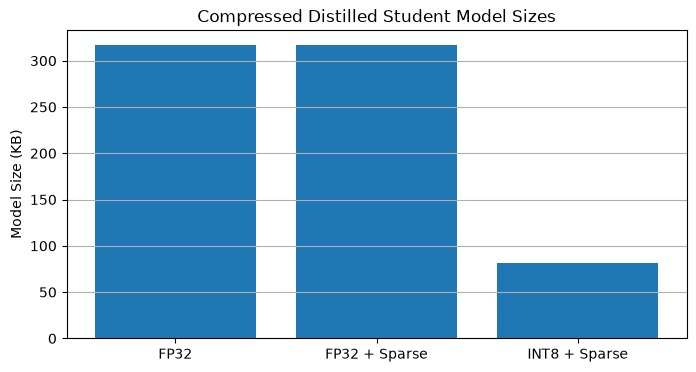

In [61]:

plt.figure(figsize=(8, 4))
plt.bar(part2_results["Format"], part2_results["Model Size (KB)"])
plt.ylabel("Model Size (KB)")
plt.title("Compressed Distilled Student Model Sizes")
plt.grid(axis="y")
plt.show()


### Confusion Matrix for the Final Sparse INT8 Distilled Student


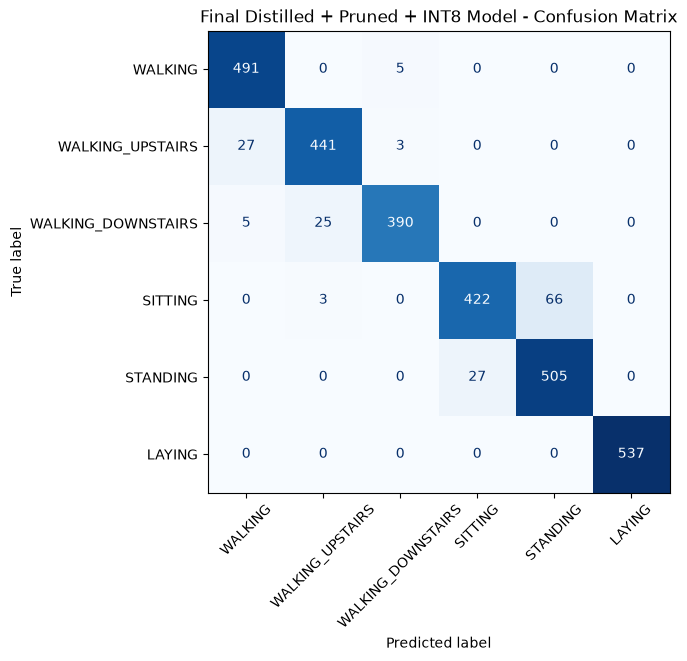

In [62]:

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, stripped_sparse_int8_preds),
    display_labels=class_names
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Final Distilled + Pruned + INT8 Model - Confusion Matrix")
plt.show()


## 20. Summary Questions

Answer the following in your lab report:
1. How did the **baseline student** compare with the **distilled student**?
2. Did **knowledge distillation** help the smaller model retain performance?
3. What happened to the model size after **pruning** and after **INT8 quantization**?
4. Which model would you choose for **Arduino deployment**, and why?
5. Why is the final **sparse INT8 model** a good TinyML deployment candidate?


## 21. Submission Requirements

Submit the following:
1. Your completed notebook
2. Screenshots of the most important results:
   - teacher accuracy
   - baseline student accuracy
   - distilled student accuracy
   - final sparse INT8 model accuracy and size
3. The exported TensorFlow Lite model:
   - `distilled_stripped_sparse_int8.tflite`
4. Short answers to the summary questions
